In [1]:
%matplotlib notebook

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ROOT
from ROOT import TFile, TTree, TCanvas, TH2D
from scipy import constants
import pandas as pd
#plt.rcParams['text.usetex'] = True

from scipy.stats import binned_statistic_2d
import plotly.graph_objects as go

Welcome to JupyROOT 6.22/09


In [3]:
print(constants.physical_constants['proton mass energy equivalent in MeV'][0]/1000)

0.93827208816


In [4]:
#f = TFile("selectedEventsPrim_041624.root","READ")
#f = TFile("selectedEventsPrim_041724_1000events.root","READ")
#f = TFile("selectedEventsSim_050824.root","READ")
f = TFile("selectedEventsSim_050924_recoTest.root","READ")
t = f.Get("selectedEvents")

e = t.GetEntries()
print(e)

19188


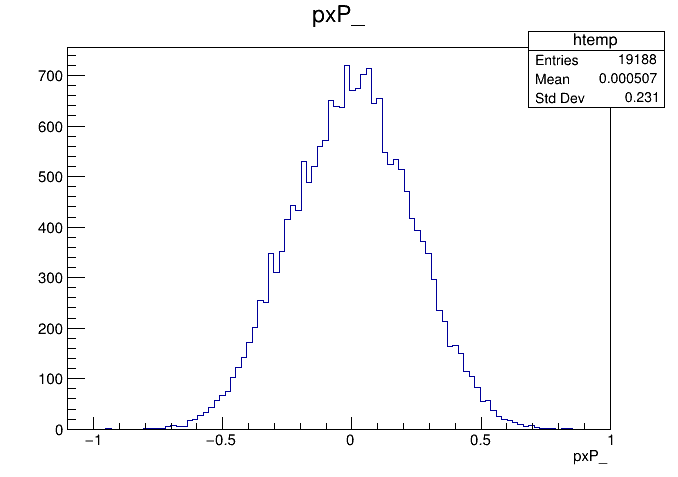

In [5]:
canvas = TCanvas("frNoSC","frNoSC",720,152,682,505)
canvas.cd()
#corr2 = TH2D("corr2","Fractional Difference vs. MCS Reco Momentum, no SC",100,0,2,100,0,2)
f.selectedEvents.Draw("pxP_","","COLZ")
#corr2.GetXaxis().SetTitle("MCS Reco Momentum, no SC [GeV]")
#corr2.GetYaxis().SetTitle("(MCS p (w/ SC) - MCS p (no SC)) / MCS p (no SC)")
canvas.Draw()

In [6]:
t.GetEntry(0)

def getTransverseAxis(eNu, pxMu, pyMu, pzMu):
    pV = np.array([0, 0, eNu])
    pMu = np.array([pxMu, pyMu, pzMu])
    z = np.cross(pV, pMu)
    magZ = np.sqrt( z[0]**2 + z[1]**2 + z[2]**2 )
    #return z / magZ
    return z / np.linalg.norm(z) # same as my magZ eqn above

print(t.eNu_)
print(t.pxMu_)

z = getTransverseAxis(t.eNu_,t.pxMu_,t.pyMu_,t.pzMu_)

print("z: ", z )
#testZ = np.array([ 0.04815974, -0.97140761, -0.23248202]) 

1.9261623620986938
0.029443029403686524
z:  [ 0.99614038  0.08777442 -0.        ]


In [7]:
print(t.modeNu_)
print(t.intrxnNu_)

1
1003


In [8]:
t.GetEntry(0)

pPi = np.array([t.pxPi_, t.pyPi_, t.pzPi_])
pP = np.array([t.pxP_, t.pyP_, t.pzP_])
print(pPi)
print(pP)

# 1st TKI observable, double-transverse momentum imbalance
def delPTT(z, pPi, pP): 
    pPiTT = np.dot(z,pPi)
    pPTT = np.dot(z,pP)
    return pPiTT + pPTT

print( delPTT(z, pPi, pP) )

[-0.19392665  0.00688269  0.2526535 ]
[0.18746324 0.32145505 0.31821021]
0.022381190864013745


In [9]:
t.GetEntry(0)
# sum of transverse momenta of the 3 particles
def delPT(pxPi, pxP, pxMu, pyPi, pyP, pyMu): 
    pTMu = np.array([pxMu, pyMu, 0])
    pTP = np.array([pxP, pyP, 0])
    pTPi = np.array([pxPi, pyPi, 0])
    return pTMu + pTPi + pTP

delPT_test = delPT(t.pxPi_, t.pxP_, t.pxMu_, t.pyPi_, t.pyP_, t.pyMu_)
print(delPT_test)

[ 0.02297962 -0.00580735  0.        ]


In [10]:
epsilon = 0.0309

t.GetEntry(0)

# longitudinal component, the long way
def pL(pzP, pzMu, pzPi, eP, eMu, ePi, delPT): 
    mP = constants.physical_constants['proton mass energy equivalent in MeV'][0]/1000 
    print("mP: ", mP)
    mN = constants.physical_constants['neutron mass energy equivalent in MeV'][0]/1000
    print("mN: ", mN)
    B = 0.34381
    mA = 22*mN + 18*mP - B
    mA1 = mA - mN + epsilon
    del2 = np.dot(delPT, delPT)
    #pLP = np.array([0, 0, pzP])
    #pLMu = np.array([0, 0, pzMu])
    #pLPi = np.array([0, 0, pzPi])
    parens = mA + pzMu + pzPi + pzP - eMu - ePi - eP
    return 0.5*(parens) - 0.5*((del2+mA1**2)/(parens))

pL_test = pL(t.pzP_, t.pzMu_, t.pzPi_, t.eP_, t.eMu_, t.ePi_, delPT_test)
print(t.pzP_)
print("pL_test: ", pL_test)

def pLGKI(pzP, pzMu, pzPi, eP, eMu, ePi):
    pRest = constants.physical_constants['proton mass energy equivalent in MeV'][0]/1000
    piRest = 139.57/1000 # GeV
    print("piRest:", piRest)
    #Ecal = eMu + (eP-pRest) + (ePi-piRest) + epsilon
    Ecal = eMu + (eP-pRest) + ePi + epsilon
    return pzMu + pzP + pzPi - Ecal

pLGKI_test = pLGKI(t.pzP_, t.pzMu_, t.pzPi_, t.eP_, t.eMu_, t.ePi_)
print("pLGKI_test: ", pLGKI_test)

mP:  0.93827208816
mN:  0.93956542052
0.318210205078125
pL_test:  0.029933857283342746
piRest: 0.13957
pLGKI_test:  0.02866060134359394


In [11]:
# 3rd TKI observable, boosting angle
def delAlphaT(pxMu, pyMu, delPT): 
    pTMu = np.array([pxMu, pyMu, 0])
    magPTMu = np.sqrt( pTMu[0]**2 + pTMu[1]**2 + pTMu[2]**2 )
    magDelPT = np.sqrt( delPT[0]**2 + delPT[1]**2 + delPT[2]**2 )
    dot = np.dot(-pTMu,delPT)
    return np.arccos(dot / (magPTMu * magDelPT))

delAlphaT_test = delAlphaT(t.pxMu_, t.pyMu_, delPT_test)
print(delAlphaT_test)

1.9062182804629555


In [ ]:
# items to plot

muMom_list = []
piMom_list = []
lPMom_list = []
muAng_list = []
piAng_list = []
lPAng_list = []

recoPiMom_list = []
recoMuMom_list = []
recoLPMom_list = []

delPTT_list = []
pL_list = []
pLGKI_list = []
pN_list = []
pNGKI_list = []
delAlphaT_list = []
mode_list = []
intrxn_list = []
recoNuE_list = []
weights_list = []

entries = t.GetEntries()

# main loop
for e in range(entries):

    t.GetEntry(e)
    
    pPi = np.array([t.pxPi_, t.pyPi_, t.pzPi_])
    pP = np.array([t.pxP_, t.pyP_, t.pzP_])
    
    z = getTransverseAxis(t.eNu_,t.pxMu_,t.pyMu_,t.pzMu_)
    delPT_entry = delPT(t.pxPi_, t.pxP_, t.pxMu_, t.pyPi_, t.pyP_, t.pyMu_)
    
    delPTT_list.append( delPTT(z, pPi, pP) )
    delAlphaT_list.append( delAlphaT(t.pxMu_, t.pyMu_, delPT_entry ) )
    
    pL_entry = pL(t.pzP_, t.pzMu_, t.pzPi_, t.eP_, t.eMu_, t.ePi_, delPT_test)
    pLGKI_entry = pLGKI(t.pzP_, t.pzMu_, t.pzPi_, t.eP_, t.eMu_, t.ePi_)
    
    pL_list.append( pL_entry )
    pLGKI_list.append( pLGKI_entry )
    
    pN = np.sqrt( np.dot(delPT_entry, delPT_entry) + np.dot(pL_entry, pL_entry) )
    pN_list.append(pN)
    
    pNGKI = np.sqrt( np.dot(delPT_entry, delPT_entry) + np.dot(pLGKI_entry, pLGKI_entry) )
    pNGKI_list.append(pNGKI)
    
    mode_list.append(t.modeNu_)
    intrxn_list.append(t.intrxnNu_)
    
    recoNuE_list.append(t.recoNuE_)
    
    muMom_list.append(t.muonMom_)
    piMom_list.append(t.pionMom_)
    lPMom_list.append(t.lProtonMom_)
    muAng_list.append(t.muonAng_)
    piAng_list.append(t.pionAng_)
    lPAng_list.append(t.lProtonAng_)
    
        
    recoMuMom_list.append(t.recoMomMu_)
    recoPiMom_list.append(t.recoMomPi_)
    recoLPMom_list.append(t.recoMomP_)
    
    weights_list.append(t.weight_)
    
    #print("pPi:", pPi)
    #print("pP:", pP)
    
#print("delPTT_list: ", delPTT_list)
print("delAlphaT_list: ", delAlphaT_list)
    
delPTT_arr = np.asarray(delPTT_list)
delAlphaT_arr = np.asarray(delAlphaT_list)
pL_arr = np.asarray(pL_list)
pLGKI_arr = np.asarray(pLGKI_list)
pN_arr = np.asarray(pN_list)
pNGKI_arr = np.asarray(pNGKI_list)
mode_arr = np.asarray(mode_list)
intrxn_arr = np.asarray(intrxn_list)
recoNuE_arr = np.asarray(recoNuE_list)
weights_arr = np.asarray(weights_list)

muMom_arr = np.asarray(muMom_list)
piMom_arr = np.asarray(piMom_list)
lPMom_arr = np.asarray(lPMom_list)
muAng_arr = np.asarray(muAng_list)
piAng_arr = np.asarray(piAng_list)
lPAng_arr = np.asarray(lPAng_list)

recoMuMom_arr = np.asarray(recoMuMom_list)
recoPiMom_arr = np.asarray(recoPiMom_list)
recoLPMom_arr = np.asarray(recoLPMom_list)
    

mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93

mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93

mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93

mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93

mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93

...

mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0

mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93

mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93

mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93

piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827208816
mN:  0.93956542052
piRest: 0.13957
mP:  0.93827

In [ ]:
print("delPTT_arr: ", delPTT_arr)
#print("delAlphaT_arr: ", delAlphaT_arr)
print("pL_arr: ", pL_arr)
print("pLGKI_arr: ", pLGKI_arr)
print("pN_arr: ", pN_arr)
print("pNGKI_arr: ", pNGKI_arr)

#print("muMom_arr: ", muMom_arr)
#print("piMom_arr: ", piMom_arr)
#print("lPMom_arr: ", lPMom_arr)
#print("muAng_arr: ", muAng_arr)
#print("piAng_arr: ", piAng_arr)
#print("lPAng_arr: ", lPAng_arr)
#print("mode_arr: ", mode_arr)
#print("intrxn_arr: ", intrxn_arr)
#print("recoNuE_arr: ", recoNuE_arr)
#print("weights_arr: ", weights_arr)


print("delPTT_arr.shape: ", delPTT_arr.shape)
print("delAlphaT_arr.shape: ", delAlphaT_arr.shape)
print("pL_arr.shape: ", pL_arr.shape)
print("pLGKI_arr.shape: ", pLGKI_arr.shape)
print("pN_arr.shape: ", pN_arr.shape)
print("pNGKI_arr.shape: ", pNGKI_arr.shape)
print("mode_arr.shape: ", mode_arr.shape)
print("intrxn_arr.shape: ", intrxn_arr.shape)

df = pd.DataFrame(
    {
        "delPTT": delPTT_arr,
        "delAlphaT": delAlphaT_arr,
        "mode": mode_arr,
        "intrxn": intrxn_arr
    }
)

print(df)

In [ ]:
#dictionary of modes/intrxns
kNuanceOffset = 1000
intrxn_dict = {'QE':0, 'Res':1, 'DIS':2, 'Coh':3,
               'CCQE':kNuanceOffset+1, #charged current quasi-elastic
               'NCQE':kNuanceOffset+2, #neutral current quasi-elastic
               'ResCCNuProtonPiPlus':kNuanceOffset+3, #resonant charged current, nu p -> l- p pi+
               'ResCCNuNeutronPi0':kNuanceOffset + 4,      # resonant charged current, nu n -> l- n pi0
               'ResCCNuNeutronPiPlus':kNuanceOffset + 5,   # resonant charged current, nu n -> l- n pi+
               'ResNCNuProtonPi0':kNuanceOffset + 6,       # resonant neutral current, nu p -> nu p pi0
               'ResNCNuProtonPiPlus':kNuanceOffset + 7, # resonant neutral current, nu p -> nu p pi+
               'ResNCNuNeutronPi0':kNuanceOffset + 8,   # resonant neutral current, nu n -> nu n pi0
               'ResNCNuNeutronPiMinus':kNuanceOffset + 9,   # resonant neutral current, nu n -> nu p pi-
               'ResCCNuBarNeutronPiMinus':kNuanceOffset + 10,  # resonant charged current, nubar n -> l+ n pi-
               'ResCCNuBarProtonPi0':kNuanceOffset + 11,  # resonant charged current, nubar p -> l+ n pi0
               'ResCCNuBarProtonPiMinus':kNuanceOffset + 12,  # resonant charged current, nubar p -> l+ p pi-
               'ResNCNuBarProtonPi0':kNuanceOffset + 13,  # resonant charged current, nubar p -> nubar p pi0
               'ResNCNuBarProtonPiPlus':kNuanceOffset + 14,  # resonant charged current, nubar p -> nubar n pi+
               'ResNCNuBarNeutronPi0':kNuanceOffset + 15,  # resonant charged current, nubar n -> nubar n pi0
               'ResNCNuBarNeutronPiMinus':kNuanceOffset + 16,  # resonant charged current, nubar n -> nubar p pi-
               'ResCCNuDeltaPlusPiPlus':kNuanceOffset + 17,
               'ResCCNuDelta2PlusPiMinus':kNuanceOffset + 21,
               'ResCCNuBarDelta0PiMinus':kNuanceOffset + 28,
               'ResCCNuBarDeltaMinusPiPlus':kNuanceOffset + 32,
               'ResCCNuProtonRhoPlus':kNuanceOffset + 39,
               'ResCCNuNeutronRhoPlus':kNuanceOffset + 41,
               'ResCCNuBarNeutronRhoMinus':kNuanceOffset + 46,
               'ResCCNuBarNeutronRho0':kNuanceOffset + 48,
               'ResCCNuSigmaPlusKaonPlus':kNuanceOffset + 53,
               'ResCCNuSigmaPlusKaon0':kNuanceOffset + 55,
               'ResCCNuBarSigmaMinusKaon0':kNuanceOffset + 60,
               'ResCCNuBarSigma0Kaon0':kNuanceOffset + 62,
               'ResCCNuProtonEta':kNuanceOffset + 67,
               'ResCCNuBarNeutronEta':kNuanceOffset + 70,
               'ResCCNuKaonPlusLambda0':kNuanceOffset + 73,
               'ResCCNuBarKaon0Lambda0':kNuanceOffset + 76,
               'ResCCNuProtonPiPlusPiMinus':kNuanceOffset + 79,
               'ResCCNuProtonPi0Pi0':kNuanceOffset + 80,
               'ResCCNuBarNeutronPiPlusPiMinus':kNuanceOffset + 85,
               'ResCCNuBarNeutronPi0Pi0':kNuanceOffset + 86,
               'ResCCNuBarProtonPi0Pi0':kNuanceOffset + 90,
               'CCDIS':kNuanceOffset + 91,  # charged current deep inelastic scatter
               'NCDIS':kNuanceOffset + 92,  # charged current deep inelastic scatter
               'UnUsed1':kNuanceOffset + 93,
               'UnUsed2':kNuanceOffset + 94,
               'CCQEHyperon':kNuanceOffset + 95,
               'NCCOH':kNuanceOffset + 96,
               'CCCOH':kNuanceOffset + 97,  # charged current coherent pion
               'NuElectronElastic':kNuanceOffset + 98,  # neutrino electron elastic scatter
               'InverseMuDecay':kNuanceOffset + 99   # inverse muon decay
               
              }

print(intrxn_dict)
flip_dict = dict((v,k) for k,v in intrxn_dict.items())

print(flip_dict)

In [ ]:
#test = np.asarray(flip_dict.values())[np.searchsorted(flip_dict.keys(),intrxn_arr)]
#test = [flip_dict[i] for i in intrxn_arr]

In [ ]:
#print(mode_list)
modeSet = set(mode_list)
print(modeSet)

In [ ]:
#print(intrxn_list)
myset = set(intrxn_list)
print(myset)

In [ ]:
# POT scaling!

targetPOT = 1.3e21
sumPOT = 8.98e20

scale = targetPOT / sumPOT
print("Scale is: ", scale)

print(np.sum(weights_arr))
totalEvents = np.sum(weights_arr)*scale
print("totalEvents: ", totalEvents)

# In this section I grab the list of entries for each mode

In [ ]:
modeZero_indices = []
modeOne_indices = []
modeTwo_indices = []
modeTen_indices = []

pN_modeZero = []
pN_modeOne = []
pN_modeTwo = []
pN_modeTen = []

weights_modeZero = []
weights_modeOne = []
weights_modeTwo = []
weights_modeTen = []

for index, item in enumerate(mode_arr):
    if item==0:
        modeZero_indices.append(index)
    if item==1:
        modeOne_indices.append(index)
    if item==2:
        modeTwo_indices.append(index)
    if item==10:
        modeTen_indices.append(index)
        
for index, item in enumerate(modeZero_indices):
    pN_modeZero.append(pN_arr[item])
    weights_modeZero.append(weights_arr[item])
    
for index, item in enumerate(modeOne_indices):
    pN_modeOne.append(pN_arr[item])
    weights_modeOne.append(weights_arr[item])
    
for index, item in enumerate(modeTwo_indices):
    pN_modeTwo.append(pN_arr[item])
    weights_modeTwo.append(weights_arr[item])

for index, item in enumerate(modeTen_indices):
    pN_modeTen.append(pN_arr[item])
    weights_modeTen.append(weights_arr[item])
    
pN_modeZero_arr=np.array(pN_modeZero)
print(len(pN_modeZero))
print(pN_modeZero_arr.shape)
print(len(weights_modeZero))
print("weights_modeZero:", weights_modeZero)

pN_modeOne_arr=np.array(pN_modeOne)
print(len(pN_modeOne))
print(pN_modeOne_arr.shape)
#print(len(weights_modeOne))
#print("weights_modeOne:", weights_modeOne)

modeTwo_indices_arr=np.array(modeTwo_indices)
print(len(modeTwo_indices))
print(modeTwo_indices_arr)
print(len(weights_modeTwo))
#print("weights_modeTwo:", weights_modeTwo)

modeTen_indices_arr=np.array(modeTen_indices)
print(len(modeTen_indices))
print(modeTen_indices_arr)
print(len(weights_modeTen))
#print("weights_modeTen:", weights_modeTen)

In [ ]:
delAlphaT_modeZero = []
delAlphaT_modeOne = []
delAlphaT_modeTwo = []
delAlphaT_modeTen = []

delAlphaT_deg = delAlphaT_arr*(180/np.pi)

for index, item in enumerate(modeZero_indices):
    delAlphaT_modeZero.append(delAlphaT_deg[item])
    
for index, item in enumerate(modeOne_indices):
    delAlphaT_modeOne.append(delAlphaT_deg[item])
    
for index, item in enumerate(modeTwo_indices):
    delAlphaT_modeTwo.append(delAlphaT_deg[item])

for index, item in enumerate(modeTen_indices):
    delAlphaT_modeTen.append(delAlphaT_deg[item])

delAlphaT_modeZero_arr=np.array(delAlphaT_modeZero)
print(len(delAlphaT_modeZero_arr))
print(delAlphaT_modeZero_arr.shape)
print(len(weights_modeZero))

In [ ]:
delPTT_modeZero = []
delPTT_modeOne = []
delPTT_modeTwo = []
delPTT_modeTen = []

for index, item in enumerate(modeZero_indices):
    delPTT_modeZero.append(delPTT_arr[item])
    
for index, item in enumerate(modeOne_indices):
    delPTT_modeOne.append(delPTT_arr[item])
    
for index, item in enumerate(modeTwo_indices):
    delPTT_modeTwo.append(delPTT_arr[item])

for index, item in enumerate(modeTen_indices):
    delPTT_modeTen.append(delPTT_arr[item])

# In this section I grab the list of entries for each intrxn

In [ ]:
intrxnA_indices = []
intrxnB_indices = []
intrxnC_indices = []
intrxnD_indices = []
intrxnE_indices = []
intrxnF_indices = []

for index, item in enumerate(intrxn_arr):
    if item==1000:
        intrxnA_indices.append(index)
    if item==1001:
        intrxnB_indices.append(index)
    if item==1003:
        intrxnC_indices.append(index)
    if item==1004:
        intrxnD_indices.append(index)
    if item==1005:
        intrxnE_indices.append(index)
    if item==1091:
        intrxnF_indices.append(index)
        
intrxnA_indices_arr=np.array(intrxnA_indices)
print(len(intrxnA_indices))
print(intrxnA_indices_arr)

In [ ]:
pN_intrxnA = []
pN_intrxnB = []
pN_intrxnC = []
pN_intrxnD = []
pN_intrxnE = []
pN_intrxnF = []

weights_intrxnA = []
weights_intrxnB = []
weights_intrxnC = []
weights_intrxnD = []
weights_intrxnE = []
weights_intrxnF = []

for index, item in enumerate(intrxnA_indices):
    pN_intrxnA.append(pN_arr[item])
    weights_intrxnA.append(weights_arr[item])
    
for index, item in enumerate(intrxnB_indices):
    pN_intrxnB.append(pN_arr[item])
    weights_intrxnB.append(weights_arr[item])

for index, item in enumerate(intrxnC_indices):
    pN_intrxnC.append(pN_arr[item])
    weights_intrxnC.append(weights_arr[item])
    
for index, item in enumerate(intrxnD_indices):
    pN_intrxnD.append(pN_arr[item])
    weights_intrxnD.append(weights_arr[item])
    
for index, item in enumerate(intrxnE_indices):
    pN_intrxnE.append(pN_arr[item])
    weights_intrxnE.append(weights_arr[item])
    
for index, item in enumerate(intrxnF_indices):
    pN_intrxnF.append(pN_arr[item])
    weights_intrxnF.append(weights_arr[item])
    


In [ ]:
delAlphaT_intrxnA = []
delAlphaT_intrxnB = []
delAlphaT_intrxnC = []
delAlphaT_intrxnD = []
delAlphaT_intrxnE = []
delAlphaT_intrxnF = []

delAlphaT_deg = delAlphaT_arr*(180/np.pi)

for index, item in enumerate(intrxnA_indices):
    delAlphaT_intrxnA.append(delAlphaT_deg[item])
    
for index, item in enumerate(intrxnB_indices):
    delAlphaT_intrxnB.append(delAlphaT_deg[item])
    
for index, item in enumerate(intrxnC_indices):
    delAlphaT_intrxnC.append(delAlphaT_deg[item])
    
for index, item in enumerate(intrxnD_indices):
    delAlphaT_intrxnD.append(delAlphaT_deg[item])
    
for index, item in enumerate(intrxnE_indices):
    delAlphaT_intrxnE.append(delAlphaT_deg[item])
    
for index, item in enumerate(intrxnF_indices):
    delAlphaT_intrxnF.append(delAlphaT_deg[item])

In [ ]:
delPTT_intrxnA = []
delPTT_intrxnB = []
delPTT_intrxnC = []
delPTT_intrxnD = []
delPTT_intrxnE = []
delPTT_intrxnF = []

for index, item in enumerate(intrxnA_indices):
    delPTT_intrxnA.append(delPTT_arr[item])
    
for index, item in enumerate(intrxnB_indices):
    delPTT_intrxnB.append(delPTT_arr[item])
    
for index, item in enumerate(intrxnC_indices):
    delPTT_intrxnC.append(delPTT_arr[item])
    
for index, item in enumerate(intrxnD_indices):
    delPTT_intrxnD.append(delPTT_arr[item])
    
for index, item in enumerate(intrxnE_indices):
    delPTT_intrxnE.append(delPTT_arr[item])
    
for index, item in enumerate(intrxnF_indices):
    delPTT_intrxnF.append(delPTT_arr[item])

# Plots!

In [ ]:
# delPTT everything together
# POT weighted

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

#counts, bins = np.histogram(delPTT_arr, bins=100)
counts, bins = np.histogram(delPTT_arr, bins=100, weights=weights_arr)
scaledCounts = counts*scale
plt.stairs(scaledCounts, bins, label="1.3e21 POT")
plt.stairs(counts, bins, label="8.98e20 POT")
#plt.hist(ntuple_muonMom, bins=100, weights=ntuple_weights)
plt.xlabel('delPTT (GeV/c)')
plt.ylabel('Counts')
plt.title('delPTT')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)

In [ ]:
ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

#counts, bins = np.histogram(delPTT_arr, bins=100)
#ax.hist(delPTT_arr, bins=100, stacked=True, histtype='bar')
#ax.hist(delPTT_modeZero, bins=100, histtype='step', stacked=True, fill=False, label='QE')
ax.hist(delPTT_modeZero, bins=100, histtype='step', stacked=True, fill=False, weights=weights_modeZero, label='QE')
#ax.hist(delPTT_modeOne, bins=100, histtype='step', stacked=True, fill=False, label='Res')
ax.hist(delPTT_modeOne, bins=100, histtype='step', stacked=True, fill=False, weights=weights_modeOne, label='Res')
#ax.hist(delPTT_modeTwo, bins=100, histtype='step', stacked=True, fill=False, label='DIS')
ax.hist(delPTT_modeTwo, bins=100, histtype='step', stacked=True, fill=False, weights=weights_modeTwo, label='DIS')
#ax.hist(delPTT_modeTen, bins=100, histtype='step', stacked=True, fill=False, label='MEC')
ax.hist(delPTT_modeTen, bins=100, histtype='step', stacked=True, fill=False, weights=weights_modeTen, label='MEC')
#ax.hist(delPTT_arr, bins=100)
#plt.stairs(counts, bins)
plt.xlabel('delPTT (GeV/c)')
plt.ylabel('Counts')
plt.legend()
plt.title('delPTT')

In [ ]:
ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

#counts, bins = np.histogram(delPTT_arr, bins=100)
#ax.hist(delPTT_arr, bins=100, stacked=True, histtype='bar')
ax.hist(delPTT_intrxnB, bins=100, histtype='step', stacked=True, fill=False, weights=weights_intrxnB, label='CCQE')
ax.hist(delPTT_intrxnC, bins=100, histtype='step', stacked=True, fill=False, weights=weights_intrxnC, label='ResCCNuProtonPiPlus')
ax.hist(delPTT_intrxnD, bins=100, histtype='step', stacked=True, fill=False, weights=weights_intrxnD, label='ResCCNuNeutronPi0')
ax.hist(delPTT_intrxnE, bins=100, histtype='step', stacked=True, fill=False, weights=weights_intrxnE, label='ResCCNuNeutronPiPlus')
ax.hist(delPTT_intrxnF, bins=100, histtype='step', stacked=True, fill=False, weights=weights_intrxnF, label='CCDIS')
ax.hist(delPTT_intrxnA, bins=100, histtype='step', stacked=True, fill=False, weights=weights_intrxnA, label='Higher Resonances')
#ax.hist(delPTT_arr, bins=100)
#plt.stairs(counts, bins)
plt.xlabel('delPTT (GeV/c)')
plt.ylabel('Counts')
plt.legend()
plt.title('delPTT')

In [ ]:
# pN everything together
# POT weighted

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

counts, bins = np.histogram(pN_arr, bins=100, weights=weights_arr)
scaledCounts = counts*scale
plt.stairs(scaledCounts, bins, label="1.3e21 POT")
plt.stairs(counts, bins, label="8.98e20 POT")
#plt.hist(ntuple_muonMom, bins=100, weights=ntuple_weights)
plt.xlabel('pN (GeV/c)')
plt.ylabel('Counts')
plt.legend(loc="upper right")
plt.title('pN')

print(pN_arr.shape)

In [ ]:
# THIS IS THE GKI ONE

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

counts, bins = np.histogram(pNGKI_arr, bins=100)
plt.stairs(counts, bins)
plt.xlabel('pN (GKI) (GeV/c)')
plt.ylabel('Counts')
plt.title('pN (GKI)')

In [ ]:
ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

#counts, bins = np.histogram(pN_arr, bins=100)
#counts, bins = np.histogram(pN_modeOne, bins=100)
#ax.hist(pN_arr, bins=100, histtype='step', stacked=True, fill=False)
ax.hist(pN_modeZero, bins=100, histtype='step', stacked=True, weights=weights_modeZero, fill=False, label='QE')
ax.hist(pN_modeOne, bins=100, histtype='step', stacked=True, weights=weights_modeOne, fill=False, label='Res')
ax.hist(pN_modeTwo, bins=100, histtype='step', stacked=True, weights=weights_modeTwo, fill=False, label='DIS')
ax.hist(pN_modeTen, bins=100, histtype='step', stacked=True, weights=weights_modeTen, fill=False, label='MEC')
#plt.stairs(counts, bins)
plt.xlabel('pN (GeV/c)')
plt.ylabel('Counts')
plt.legend()
plt.title('pN')

In [ ]:
ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

ax.hist(pN_intrxnB, bins=100, histtype='step', stacked=True, fill=False, weights=weights_intrxnB, label='CCQE')
ax.hist(pN_intrxnC, bins=100, histtype='step', stacked=True, fill=False, weights=weights_intrxnC, label='ResCCNuProtonPiPlus')
ax.hist(pN_intrxnD, bins=100, histtype='step', stacked=True, fill=False, weights=weights_intrxnD, label='ResCCNuNeutronPi0')
ax.hist(pN_intrxnE, bins=100, histtype='step', stacked=True, fill=False, weights=weights_intrxnE, label='ResCCNuNeutronPiPlus')
ax.hist(pN_intrxnF, bins=100, histtype='step', stacked=True, fill=False, weights=weights_intrxnF, label='CCDIS')
ax.hist(pN_intrxnA, bins=100, histtype='step', stacked=True, fill=False, weights=weights_intrxnA, label='Higher Resonances')

plt.xlabel('pN (GeV/c)')
plt.ylabel('Counts')
plt.legend()
plt.title('pN')

In [ ]:
# delAlphaT everything together
# POT weighted

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

counts, bins = np.histogram(delAlphaT_deg, bins=10, weights=weights_arr)
scaledCounts = counts*scale
plt.stairs(scaledCounts, bins, label="1.3e21 POT")
plt.stairs(counts, bins, label="8.98e20 POT")
#plt.hist(ntuple_muonMom, bins=100, weights=ntuple_weights)
plt.xlabel('delAlphaT (deg)')
plt.ylabel('Counts')
plt.legend(loc="upper left")
plt.title('delAlphaT')

#handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles, labels)

In [ ]:
ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)
#counts, bins = np.histogram(delAlphaT_deg, bins=10)
ax.hist(delAlphaT_modeZero, bins=10, histtype='step', stacked=True, fill=False, weights=weights_modeZero, label='QE')
ax.hist(delAlphaT_modeOne, bins=10, histtype='step', stacked=True, fill=False, weights=weights_modeOne, label='Res')
ax.hist(delAlphaT_modeTwo, bins=10, histtype='step', stacked=True, fill=False, weights=weights_modeTwo, label='DIS')
ax.hist(delAlphaT_modeTen, bins=10, histtype='step', stacked=True, fill=False, weights=weights_modeTen, label='MEC')
#plt.stairs(counts, bins)
plt.xlabel('delAlphaT (deg)')
plt.ylabel('Counts')
plt.legend(loc="upper left")
plt.title('delAlphaT')

In [ ]:
ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

ax.hist(delAlphaT_intrxnB, bins=10, histtype='step', stacked=True, fill=False, weights=weights_intrxnB, label='CCQE')
ax.hist(delAlphaT_intrxnC, bins=10, histtype='step', stacked=True, fill=False, weights=weights_intrxnC, label='ResCCNuProtonPiPlus')
ax.hist(delAlphaT_intrxnD, bins=10, histtype='step', stacked=True, fill=False, weights=weights_intrxnD, label='ResCCNuNeutronPi0')
ax.hist(delAlphaT_intrxnE, bins=10, histtype='step', stacked=True, fill=False, weights=weights_intrxnE, label='ResCCNuNeutronPiPlus')
ax.hist(delAlphaT_intrxnF, bins=10, histtype='step', stacked=True, fill=False, weights=weights_intrxnF, label='CCDIS')
ax.hist(delAlphaT_intrxnA, bins=10, histtype='step', stacked=True, fill=False, weights=weights_intrxnA, label='Higher Resonances')

plt.xlabel('delAlphaT (deg)')
plt.ylabel('Counts')
plt.legend(loc="upper left")
plt.title('delAlphaT')

In [ ]:
ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

#x, y = np.histogram2d(pL_arr, pLGKI_arr)

#pL_arr[pL_arr==0] = np.NaN
#pLGKI_arr[pLGKI_arr==0] = np.NaN

#matplotlib axes are x, y
plt.hist2d(pLGKI_arr, pL_arr, bins=(50, 50), cmap=plt.cm.Greys)
#plt.hist2d(pLGKI_arr, pL_arr, bins=(50, 50), range=np.array([(-1, 1), (-1, 1)]), cmap=plt.cm.jet)
plt.show()
#xlim([-6, 6])
#ylim([-4.5, 4.5])
#plt.imshow(x,y)
#plt.stairs(x, y)
#ax.set(xlim=(-2, 2), ylim=(-2, 2))
plt.xlabel('pL (GKI)')
ax.set_yticks([-2.00, -1.75, -1.50, -1.25, -1.00, -0.75, -0.50, -0.25, 0, 0.25, 0.50]) 
ax.set_xticks([-2.00, -1.75, -1.50, -1.25, -1.00, -0.75, -0.50, -0.25, 0, 0.25, 0.50]) 
plt.ylabel('pL (old)')
plt.colorbar(extend='both')
plt.clim(1, 1600);
#plt.title('delAlphaT')

In [ ]:
ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)
#counts, bins = np.histogram(delAlphaT_deg, bins=10)
ax.hist(recoNuE_arr, range=[-1, 2000], bins=100, histtype='step', stacked=True, fill=False, label='reco')
ax.hist(recoNuE_arr, range=[-1, 2000], bins=100, histtype='step', stacked=True, fill=False, weights=weights_arr, label='reco weighted')
#ax.hist(delAlphaT_modeOne, bins=100, histtype='step', stacked=True, fill=False, label='Res')
#ax.hist(delAlphaT_modeTwo, bins=100, histtype='step', stacked=True, fill=False, label='DIS')
#ax.hist(delAlphaT_modeTen, bins=100, histtype='step', stacked=True, fill=False, label='MEC')
#plt.stairs(counts, bins)
plt.xlabel('Energy (MeV/c)')
plt.ylabel('Counts')
plt.legend(loc="upper left")
plt.title('Reconstructed Nu Energy')

In [ ]:
h = ROOT.TH1F("gauss","Example histogram",100,-4,4)
h.FillRandom("gaus")

In [ ]:
c = ROOT.TCanvas("myCanvasName","The Canvas Title",800,600)
h.Draw()
c.Draw()

In [ ]:
targetPOT = 1.3e21
sumPOT = 8.98e20

scale = targetPOT / sumPOT
print("Scale is: ", scale)

print(np.sum(weights_list))
totalEvents = np.sum(weights_list)*scale
print("totalEvents: ", totalEvents)

In [ ]:
# muon momentum

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

print(muMom_arr.shape)

#counts, bins = np.histogram(delPTT_arr, bins=100)
counts, bins = np.histogram(muMom_arr, bins=100, weights=weights_arr)
scaledCounts = counts*scale
plt.stairs(scaledCounts, bins, label="1.3e21 POT")
plt.stairs(counts, bins, label="8.98e20 POT")
#plt.hist(ntuple_muonMom, bins=100, weights=ntuple_weights)
plt.xlabel('Muon Momentum (MeV/c)')
plt.ylabel('Counts')
plt.title('Muon Momentum Distribution')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)

In [ ]:
# pion momentum

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

counts, bins = np.histogram(piMom_arr, bins=100, weights=weights_arr)
scaledCounts = counts*scale
plt.stairs(scaledCounts, bins, label="1.3e21 POT")
plt.stairs(counts, bins, label="8.98e20 POT")
plt.xlabel('Pion Momentum (MeV/c)')
plt.ylabel('Counts')
plt.title('Pion Momentum Distribution')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)

In [ ]:
# leading proton momentum

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

counts, bins = np.histogram(lPMom_arr, bins=100, weights=weights_arr)
scaledCounts = counts*scale
plt.stairs(scaledCounts, bins, label="1.3e21 POT")
plt.stairs(counts, bins, label="8.98e20 POT")
plt.xlabel('Leading Proton Momentum (MeV/c)')
plt.ylabel('Counts')
plt.title('Leading Proton Momentum Distribution')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)

In [ ]:
# muon angle

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

counts, bins = np.histogram(muAng_arr, bins=20, weights=weights_arr)
scaledCounts = counts*scale
plt.stairs(scaledCounts, bins, label="1.3e21 POT")
plt.stairs(counts, bins, label="8.98e20 POT")
plt.xlabel('cos(theta)')
plt.ylabel('Counts')
plt.title('Muon Angle wrt Beam')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper left')

In [ ]:
# pion angle

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

counts, bins = np.histogram(piAng_arr, bins=20, weights=weights_arr)
scaledCounts = counts*scale
plt.stairs(scaledCounts, bins, label="1.3e21 POT")
plt.stairs(counts, bins, label="8.98e20 POT")
plt.xlabel('cos(theta)')
plt.ylabel('Counts')
plt.title('Pion Angle wrt Beam')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper left')

In [ ]:
# leading proton angle

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

counts, bins = np.histogram(lPAng_arr, bins=20, weights=weights_arr)
scaledCounts = counts*scale
plt.stairs(scaledCounts, bins, label="1.3e21 POT")
plt.stairs(counts, bins, label="8.98e20 POT")
plt.xlabel('cos(theta)')
plt.ylabel('Counts')
plt.title('Leading Proton Angle wrt Beam')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper left')

# Reco Plots!!!

In [ ]:
# reco muon momentum

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

counts, bins = np.histogram(recoMuMom_arr, bins=100, weights=weights_arr)
scaledCounts = counts*scale
plt.stairs(scaledCounts, bins, label="1.3e21 POT")
plt.stairs(counts, bins, label="8.98e20 POT")
#plt.hist(ntuple_muonMom, bins=100, weights=ntuple_weights)
plt.xlabel('Reco Muon Momentum (GeV/c)')
plt.ylabel('Counts')
plt.title('Reco Muon Momentum Distribution')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)

In [ ]:
# reco pion momentum

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

counts, bins = np.histogram(recoPiMom_arr, bins=100, weights=weights_arr)
scaledCounts = counts*scale
plt.stairs(scaledCounts, bins, label="1.3e21 POT")
plt.stairs(counts, bins, label="8.98e20 POT")
plt.xlabel('Reco Pion Momentum (GeV/c)')
plt.ylabel('Counts')
plt.title('Reco Pion Momentum Distribution')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)

In [ ]:
# reco leading proton momentum

ax = plt.figure().gca()
ax.yaxis.get_major_locator().set_params(integer=True)

print("recoLPMom_arr: ", recoLPMom_arr)
print("recoLPMom_arr.shape: ", recoLPMom_arr.shape)

counts, bins = np.histogram(recoLPMom_arr, bins=100, weights=weights_arr)
scaledCounts = counts*scale
plt.stairs(scaledCounts, bins, label="1.3e21 POT")
plt.stairs(counts, bins, label="8.98e20 POT")
plt.xlabel('Reco Leading Proton Momentum (GeV/c)')
plt.ylabel('Counts')
plt.title('Reco Leading Proton Momentum Distribution')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)